## Trần Nhật Trường
## MSSV: 24120486
## Bài tập về nhà buổi 1

### Cài đặt các thư viện cần thiết tránh trường hợp máy hay môi trường ảo chưa có sẵn

In [1]:
!pip install -q matplotlib
!pip install -q numpy

### Import các thư viện cần thiết trong bài tập tuần này

In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Tạo data cho bài tập. Trong này chọn dùng text

In [3]:
cau = ["I love HCMUS", "I love HCMUT", "I love UIT", "I love VNU", "We are VNU",
      "I hate VNU", "I am a student of HCMUS", "I don't know anything about IT", "I am an IT expert"]
print("số câu là:",len(cau))


số câu là: 9


### Bài 1: Biểu diễn dữ liệu thành ma trận và độ tương đồng

#### 1. Biến dữ liệu thành ma trận

In [4]:
vocab = sorted({w for s in cau for w in s.lower().split()})
def to_vector(s):
    v=np.zeros(len(vocab))
    for w in s.lower().split():
        if w not in vocab :
            continue
        v[vocab.index(w)] += 1
    return v
X = np.array([to_vector(s) for s in cau])
print(X.shape)

(9, 20)


- Trong ma trận X hiện tại, ta có mỗi hàng đại diện cho 1 câu, mỗi cột đại diện cho số lần xuất hiện của 1 từ trong câu. Khi nhìn vào ma trận này, ta có thể biết câu nào đang chứa từ gì và đang chứa bao nhiêu từ đó. 

#### 2. Phép toán cơ bản

In [5]:
meanColumn =np.mean(X,axis=0)
print("Shape của X là:", X.shape)
print("Shape của vector trung bình theo cột là:", meanColumn.shape)
subMatrix= X - meanColumn
print("Shape của ma trận hiệu là:",subMatrix.shape)

Shape của X là: (9, 20)
Shape của vector trung bình theo cột là: (20,)
Shape của ma trận hiệu là: (9, 20)


- Numpy tự broadcasting thành (20,) thành (9,20) để thực hiện phép trừ

#### 3. Cosine similarity và 4. truy vấn

In [6]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y=X
    # thêm điều kiện để tránh chuỗi rỗng hoạt không có từ nào trong tập từ của ta
    X_norm= np.linalg.norm(X, axis=1, keepdims=True)
    Y_norm= np.linalg.norm(Y, axis=1, keepdims=True)
    X_norm[X_norm== 0]= 1
    Y_norm[Y_norm== 0]= 1
    Xn= X/ X_norm
    Yn= Y/ Y_norm
    return Xn @ Yn.T

def search(query, top_k=3):
    vectorQuery = to_vector(query)
    vectorQuery = vectorQuery.reshape(1,-1)
    scores = cosine_similarity(vectorQuery,X)[0]
    sortedIdx = np.argsort(scores)[::-1]
    results = []
    for i in sortedIdx[:top_k]:
        result = {
            'index': int(i),
            'câu': (cau[i]),
            'cosineScore': float(scores[i])
        }
        results.append(result)
    return results
query = "I love you"
print('query:', query)
print(search(query))

query: I love you
[{'index': 0, 'câu': 'I love HCMUS', 'cosineScore': 0.816496580927726}, {'index': 2, 'câu': 'I love UIT', 'cosineScore': 0.816496580927726}, {'index': 1, 'câu': 'I love HCMUT', 'cosineScore': 0.816496580927726}]


#### 5. nhận xét

In [7]:
S = cosine_similarity(X)
distinctScores = {}
for i in range(S.shape[0]):
    for j in range(i+1,S.shape[1]):
        distinctScores[(i,j)]=float(S[i][j])

distinctScores = sorted(distinctScores.items(), key = lambda x: x[1])
print(f"Trong tập text ban đầu cặp giống nhau nhất là:  {cau[distinctScores[-1][0][0]]} và {cau[distinctScores[-1][0][1]]} với chỉ số tương đồng là: {distinctScores[-1][1]}")
print(f"Trong tập text ban đầu cặp khác biệt nhất là: {cau[distinctScores[0][0][0]]} và {cau[distinctScores[0][0][1]]} với chỉ số tương đồng là: {distinctScores[0][1]}")

Trong tập text ban đầu cặp giống nhau nhất là:  I love VNU và I hate VNU với chỉ số tương đồng là: 0.6666666666666669
Trong tập text ban đầu cặp khác biệt nhất là: I love HCMUS và We are VNU với chỉ số tương đồng là: 0.0


- Hiện tại kết quả cho thấy nó khớp với trực giác về mặt đếm từ nhưng về nghĩa thì chưa được chính xác vì cái tương đồng nhất thì có số từ giống nhau nhiều nhưng lại có nghĩa trái ngược nhau. Đối với 2 từ khác biệt nhất thì đúng trực giác về đếm từ vì không có từ nào trùng lặp. Nên hệ thống hoạt động ổn về phần tính tương đồng theo số từ xuất hiện bên trong nó.

### 2. Bài 2: Biến đổi tuyến tính và SVD

(9, 2)


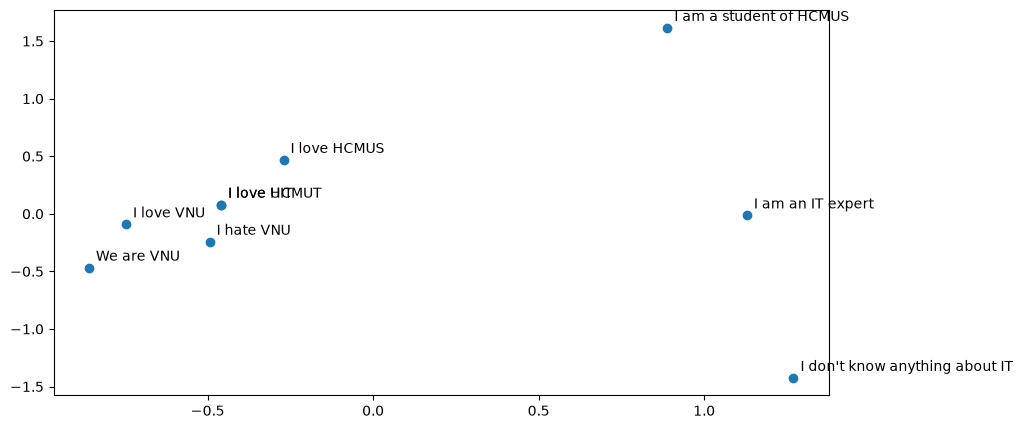

In [8]:
Xc = X- X.mean(axis =0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
coords = U[:,:2]* S[:2]
print(coords.shape)
plt.figure(figsize = (10,5))
label = cau
plt.scatter(x=coords[:,0], y=coords[:,1])
for i, txt in enumerate(label):
    plt.annotate(
        txt,
        (coords[i,0],coords[i,1]),
        xytext = (5,5),
        textcoords="offset points"
    )
plt.show()

### Nhận xét:

- Các câu có cùng chủ đề thì đứng gần nhau vì ma trận xây dựng theo đếm từ xuất hiện mà các câu có cùng chủ đề ở trong tập text ban đầu thì xuất hiện các từ đó trùng lặp nhiều. 
- Với 2 chiểu quan trọng nhất của dữ liệu sau khi dùng SVD ép về (2 chiều chứa nhiều thông tin hay biến thiên nhiều nhất của dữ liệu), lúc này số trục giảm nhưng vẫn giữ lại được cấu trúc quan trọng và vẫn cho thấy các câu có nhiều từ trùng lặp thì vẫn ở gần nhau và ít từ trùng lặp thì ở xa nhau hơn. Điều này tương tự PCA: SVD tìm các hướng/trục chính có mức biến thiên lớn nhất, rồi chiếu dữ liệu lên các trục đó để giảm chiều.

### Bonus

#### gán nhãn cho từng câu:

In [9]:
labels = [
    "school",
    "school",
    "school",
    "school",
    "school",
    "school",
    "student",
    "it",
    "it"
]

#### Hàm phân loại 1-NN

In [10]:
def classify_1nn(query):
    vectorQuery = to_vector(query)
    vectorQuery = vectorQuery.reshape(1,-1)
    scores = cosine_similarity(vectorQuery, X)[0]

    idxNearest = np.argmax(scores)
    return {
        'query': query,
        'câu gần nhất': cau[idxNearest],
        'cosine_score': float(scores[idxNearest]),
        'label dự đoán': labels[idxNearest]
    }
print(classify_1nn("I love HCMUTE"))
print(classify_1nn("I am learning IT"))

{'query': 'I love HCMUTE', 'câu gần nhất': 'I love HCMUS', 'cosine_score': 0.816496580927726, 'label dự đoán': 'school'}
{'query': 'I am learning IT', 'câu gần nhất': 'I am an IT expert', 'cosine_score': 0.7745966692414834, 'label dự đoán': 'it'}


- Hàm sẽ hoạt động theo kiểu là tìm từ có consine gần nó nhất sau đó lấy nhãn từ câu gần nhất đó để biết chủ đề đang được nhắc đến là gì.